# Child Mind Institute: Detect Sleep States - Data Exploration
This notebook performs a preliminary analysis of the dataset, visualizes the extremely long time series, and plots the `anglez` and `enmo` signals along with the sleep onset/wakeup ground truth labels.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.parquet as pq
import gc

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (20, 8)


## 1. Events Data Analysis
Let's load the `train_events.csv` and check the distribution of events and missing values.


In [8]:
events_df = pd.read_csv('../child-mind-institute-detect-sleep-states/train_events.csv')
display(events_df.head())

print(f"Total events: {len(events_df)}")
print(f"Unique series_id: {events_df['series_id'].nunique()}")
print("\nMissing values per column:")
print(events_df.isnull().sum())

# Clean missing values for plotting later
clean_events = events_df.dropna().copy()


,series_id,night,event,step,timestamp
0,038441c925bb,1,onset,4992.0,2018-08-14T22:26:00-0400
1,038441c925bb,1,wakeup,10932.0,2018-08-15T06:41:00-0400
2,038441c925bb,2,onset,20244.0,2018-08-15T19:37:00-0400
3,038441c925bb,2,wakeup,27492.0,2018-08-16T05:41:00-0400
4,038441c925bb,3,onset,39996.0,2018-08-16T23:03:00-0400


Total events: 14508
Unique series_id: 277

Missing values per column:
series_id       0
night           0
event           0
step         4923
timestamp    4923
dtype: int64


## 2. Load Parquet Time Series (Single Subject)
The `train_series.parquet` is nearly 1GB. Loading the whole file into pandas will take massive memory. We will use PyArrow to selectively load a single `series_id` for visualization.


In [ ]:
# Select a series_id that has complete events (no NaN)
valid_series = clean_events['series_id'].value_counts()
target_series_id = valid_series.index[0]
print(f"Selected series_id for visualization: {target_series_id}")

# We can read row groups sequentially until we find our target, but PyArrow allows filtering via dataset API
import pyarrow.dataset as ds
dataset = ds.dataset('../child-mind-institute-detect-sleep-states/train_series.parquet', format='parquet')
series_df = dataset.to_table(filter=ds.field('series_id') == target_series_id).to_pandas()

# Convert timestamp to datetime (handling timezones)
series_df['timestamp'] = pd.to_datetime(series_df['timestamp'], utc=True).dt.tz_convert('America/New_York').dt.tz_localize(None)

display(series_df.head())
print(f"Shape of sequence for this single subject: {series_df.shape}")


Selected series_id for visualization: a9a2f7fac455


,series_id,step,timestamp,anglez,enmo
0,a9a2f7fac455,0,2017-10-27 16:45:00,-62.350899,0.0927
1,a9a2f7fac455,1,2017-10-27 16:45:05,-26.707100,0.0408
2,a9a2f7fac455,2,2017-10-27 16:45:10,-33.740601,0.0509
3,a9a2f7fac455,3,2017-10-27 16:45:15,24.313400,0.0833
4,a9a2f7fac455,4,2017-10-27 16:45:20,27.792000,0.0305


Shape of sequence for this single subject: (634680, 5)


## 3. Visualize Sleep Cycles
We will plot `anglez` (arm angle) and `enmo` (movement) over time, and overlay the onset/wakeup events.


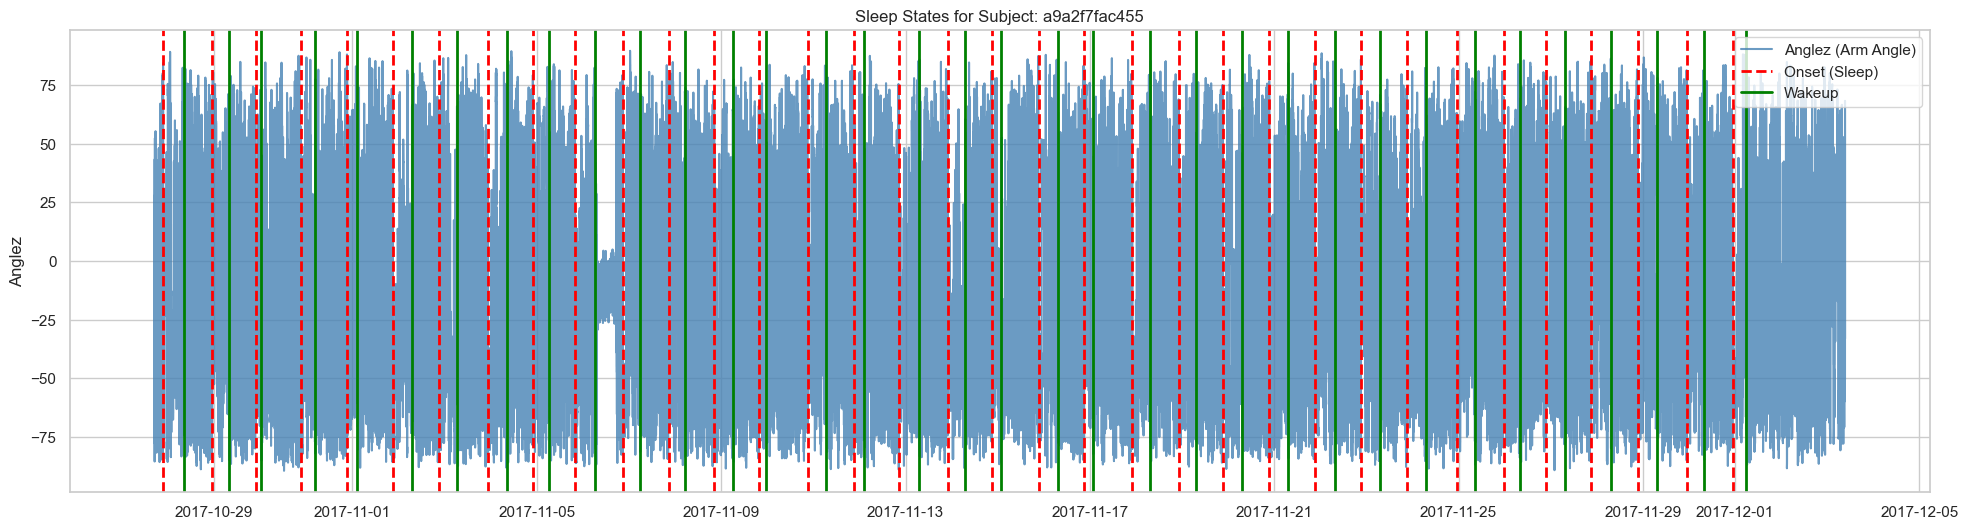

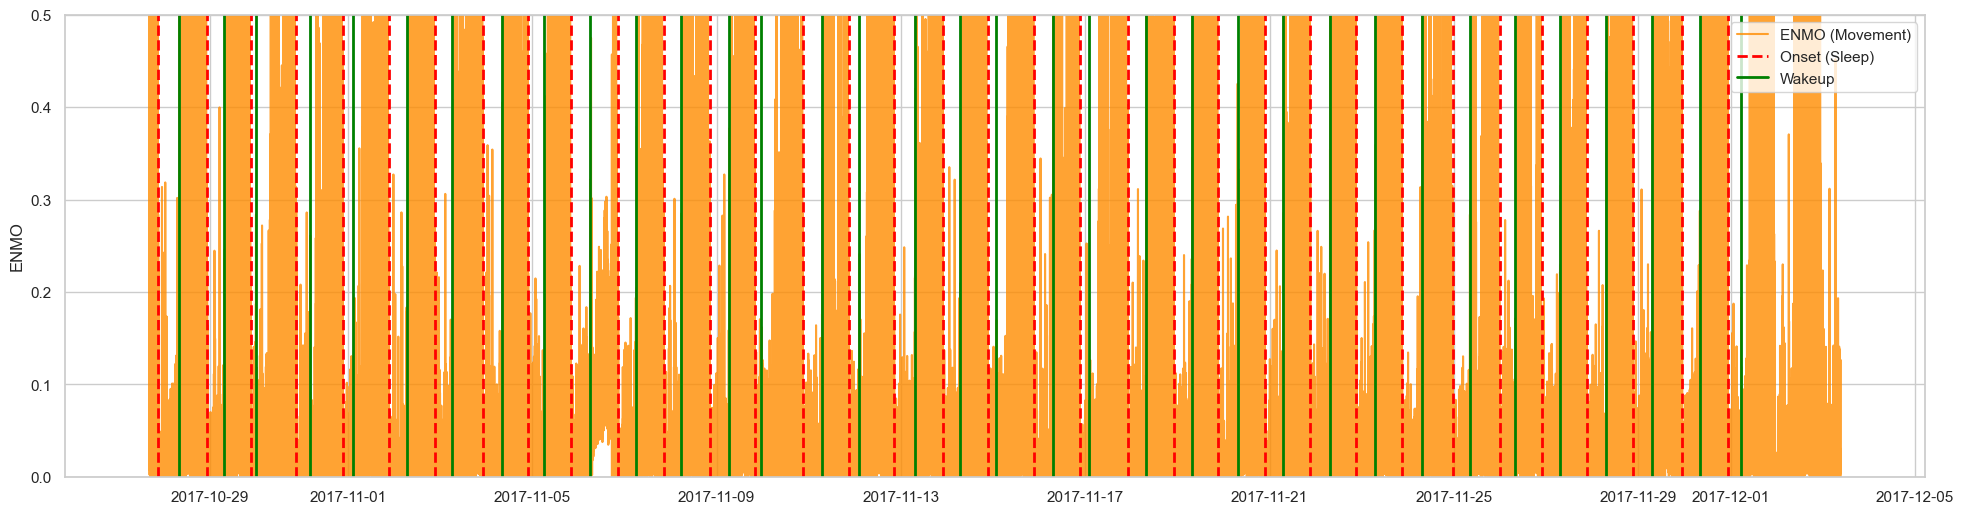

In [10]:
# Extract events for this specific series
subject_events = clean_events[clean_events['series_id'] == target_series_id].copy()
subject_events['timestamp'] = pd.to_datetime(subject_events['timestamp'], utc=True).dt.tz_convert('America/New_York').dt.tz_localize(None)

# Plot Anglez
fig, ax1 = plt.subplots(figsize=(24, 6))
ax1.plot(series_df['timestamp'], series_df['anglez'], color='steelblue', alpha=0.8, label='Anglez (Arm Angle)')
ax1.set_ylabel('Anglez')
ax1.set_title(f'Sleep States for Subject: {target_series_id}')

# Overlay events
added_onset = False
added_wakeup = False
for _, row in subject_events.iterrows():
    if row['event'] == 'onset':
        ax1.axvline(x=row['timestamp'], color='red', linestyle='--', lw=2, label='Onset (Sleep)' if not added_onset else "")
        added_onset = True
    else:
        ax1.axvline(x=row['timestamp'], color='green', linestyle='-', lw=2, label='Wakeup' if not added_wakeup else "")
        added_wakeup = True

ax1.legend(loc='upper right')
plt.show()

# Plot ENMO (Movement)
fig, ax2 = plt.subplots(figsize=(24, 6))
ax2.plot(series_df['timestamp'], series_df['enmo'], color='darkorange', alpha=0.8, label='ENMO (Movement)')
ax2.set_ylabel('ENMO')
ax2.set_ylim(0, 0.5) # Clip extreme outliers for better visualization

added_onset = False
added_wakeup = False
for _, row in subject_events.iterrows():
    if row['event'] == 'onset':
        ax2.axvline(x=row['timestamp'], color='red', linestyle='--', lw=2, label='Onset (Sleep)' if not added_onset else "")
        added_onset = True
    else:
        ax2.axvline(x=row['timestamp'], color='green', linestyle='-', lw=2, label='Wakeup' if not added_wakeup else "")
        added_wakeup = True

ax2.legend(loc='upper right')
plt.show()


## 4. Zoomed-in Visualization (2 Days)
The previous plots squished weeks of data together. Let's slice out a 48-hour window to see the exact micro-movements right around the sleep onset and wakeup events.


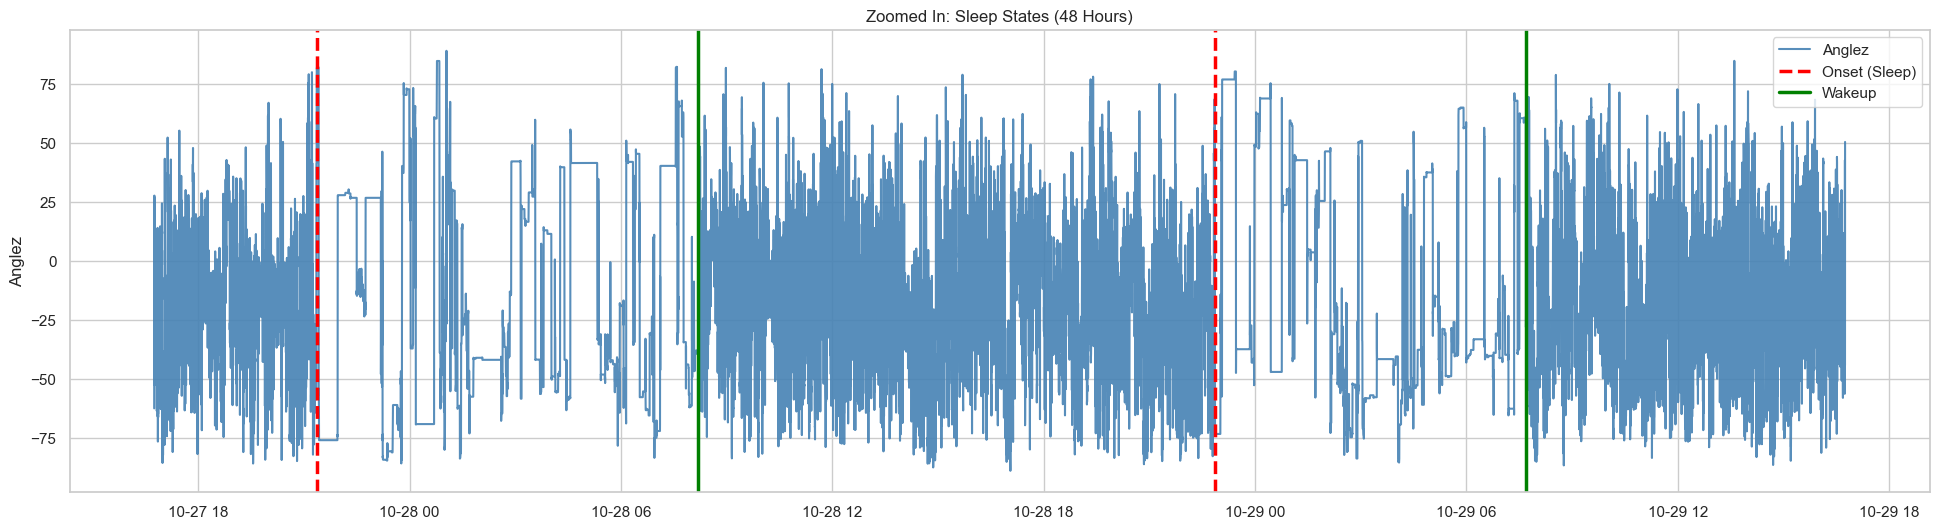

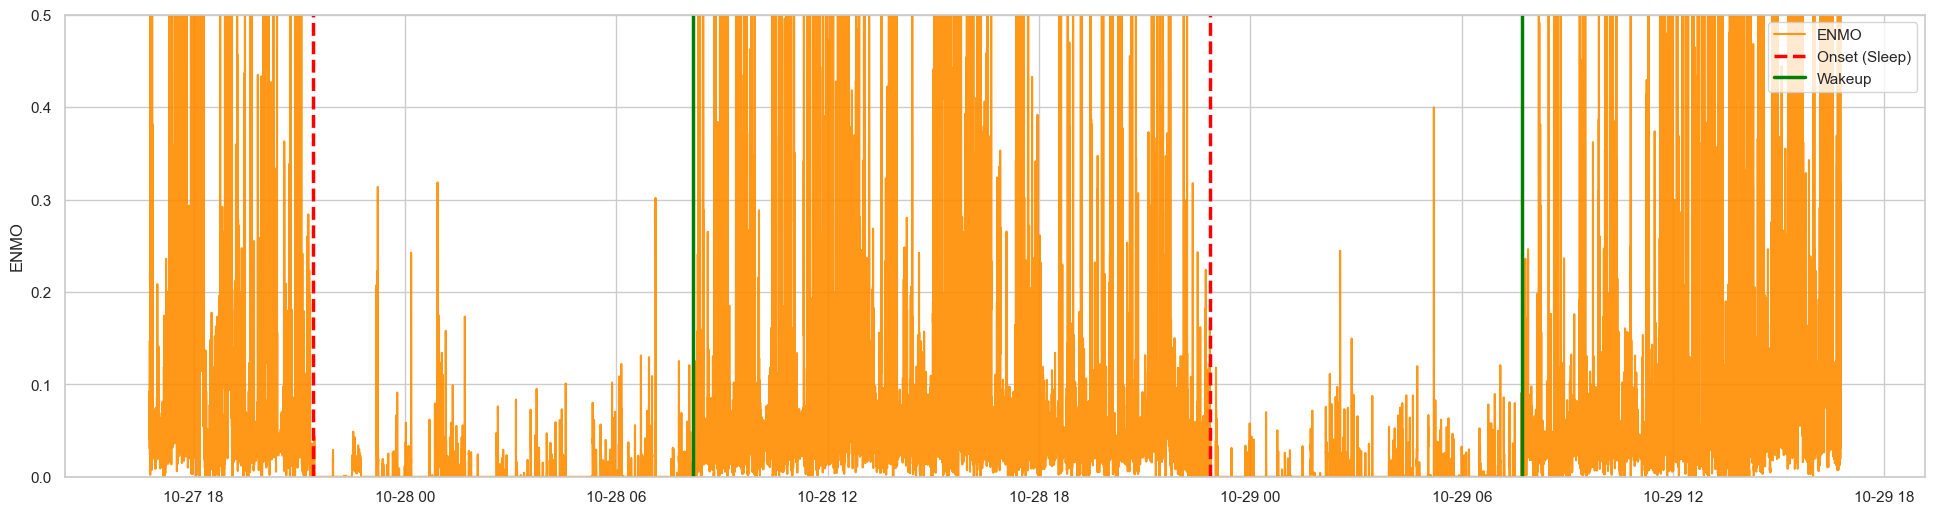

In [11]:
# Let's slice the first 2 days from the start of the data
start_time = series_df['timestamp'].min()
end_time = start_time + pd.Timedelta(days=2)

# Filter data
slice_df = series_df[(series_df['timestamp'] >= start_time) & (series_df['timestamp'] <= end_time)]
slice_events = subject_events[(subject_events['timestamp'] >= start_time) & (subject_events['timestamp'] <= end_time)]

# Plot Anglez (Zoomed)
fig, ax1 = plt.subplots(figsize=(24, 6))
ax1.plot(slice_df['timestamp'], slice_df['anglez'], color='steelblue', alpha=0.9, label='Anglez')
ax1.set_ylabel('Anglez')
ax1.set_title(f'Zoomed In: Sleep States (48 Hours)')

added_onset = False
added_wakeup = False
for _, row in slice_events.iterrows():
    if row['event'] == 'onset':
        ax1.axvline(x=row['timestamp'], color='red', linestyle='--', lw=2.5, label='Onset (Sleep)' if not added_onset else "")
        added_onset = True
    else:
        ax1.axvline(x=row['timestamp'], color='green', linestyle='-', lw=2.5, label='Wakeup' if not added_wakeup else "")
        added_wakeup = True

ax1.legend(loc='upper right')
plt.show()

# Plot ENMO (Zoomed)
fig, ax2 = plt.subplots(figsize=(24, 6))
ax2.plot(slice_df['timestamp'], slice_df['enmo'], color='darkorange', alpha=0.9, label='ENMO')
ax2.set_ylabel('ENMO')
ax2.set_ylim(0, 0.5)

added_onset = False
added_wakeup = False
for _, row in slice_events.iterrows():
    if row['event'] == 'onset':
        ax2.axvline(x=row['timestamp'], color='red', linestyle='--', lw=2.5, label='Onset (Sleep)' if not added_onset else "")
        added_onset = True
    else:
        ax2.axvline(x=row['timestamp'], color='green', linestyle='-', lw=2.5, label='Wakeup' if not added_wakeup else "")
        added_wakeup = True

ax2.legend(loc='upper right')
plt.show()
